In [1]:
# packages
import numpy as np 
import matplotlib.pyplot as plt
from matplotlib.patches import RegularPolygon
import os
import astropy.units as u

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

# creating a folder to save the plots
pltpath = 'plots/'

dpi      = 400     # resolution of saved images
formatIm = '.pdf'  # format of saved images

In [2]:
def plot_square(center, side, ax, c="k", lw=0.8):
    # Calculate the coordinates of the square's corners
    half_side = side / 2
    x_left   = center[0] - half_side
    x_right  = center[0] + half_side
    y_bottom = center[1] - half_side
    y_top    = center[1] + half_side
    
    ax.plot([x_left, x_right],  [y_top, y_top],       color=c, lw=lw)   # top side
    ax.plot([x_right, x_right], [y_top, y_bottom],    color=c, lw=lw)   # right side
    ax.plot([x_right, x_left],  [y_bottom, y_bottom], color=c, lw=lw)   # bottom side
    ax.plot([x_left, x_left],   [y_bottom, y_top],    color=c, lw=lw)   # left side
    

def fill_square(center, side, ax, fc="lightgray"):
    # Calculate the coordinates of the square's corners
    half_side = side / 2
    x_left   = center[0] - half_side
    x_right  = center[0] + half_side
    y_bottom = center[1] - half_side
    y_top    = center[1] + half_side
    
    x_range = np.linspace(x_left, x_right, 100) # Fill between values
    ax.fill_between(x_range, y_bottom, y_top, color=fc)

def plot_magic(ax, x_center=0.0, y_center=0.0, mirror_separation=0.0, lw=0.8, c="k", fc="lightgray", **kwargs):
    
    # Size of a square MAGIC mirror is 1m
    # https://cds.cern.ch/record/963488/files/15283-ita-bastieri-D-abs1-og27-poster.pdf
    # Actually is 0.5m if we divide mirrors in 4 that is done in some of the main mirrors
    mirror_side = 1.0
    
    # Grid points centered in given coordinates
    X, Y = np.arange(-8, 9) + x_center, np.arange(-8, 9) + y_center
    # Relative separation between mirrors
    relative_separation = (mirror_side - mirror_separation) / mirror_side
    for x in X:
        for y in Y:
            # Plotting for all cells within 9.2m (by test and er_ringsor) except the central one
            if [x, y] != [x_center, y_center] and np.sqrt((x - x_center)**2 + (y - y_center)**2) < 9.2:
                plot_square([x,y], mirror_side * relative_separation, ax, c=c, lw=lw, **kwargs)
                fill_square([x,y], mirror_side * relative_separation, ax, fc=fc, **kwargs)


In [3]:

def plot_hess12(ax, x_center=0.0, y_center=0.0, mirror_size_scale=1.0, lw=0.8, c="k", fc="lightgray", **kwargs):

    # HESS 12m telescope have circular mirrors of 0.6m diamter
    # https://www.mpi-hd.mpg.de/hfm/HESS/pages/about/telescopes/
    # We use a slightly smaller radius in order to avoid visual arctifacts, separating a bit more the mirrors
    mirror_radius = 0.26

    # Hard-coded factors. Given the way the geometry was defined initially.
    separation_factor = 1.2 * (0.435 / mirror_radius)
    full_scale_factor = mirror_radius / 0.435

    standard_angles = np.deg2rad([30, 90, 150, 210, 270, 330])
    standard_radius = np.arange(2, 13)

    # The angles to plot for each radial arch
    angles_ar_ringsay = [
        standard_angles[1::3], standard_angles[[True, False, True, True, False, True]],
        standard_angles, standard_angles, standard_angles, standard_angles, standard_angles, standard_angles - np.deg2rad(30)
    ]
    # Each radial arch radius
    radius_ar_ringsay = [
        standard_radius, standard_radius[:-1], standard_radius[2:], standard_radius[4:], standard_radius[6:], standard_radius[8:],
        standard_radius[10:], standard_radius[0] / 2 * np.ar_ringsay([3.18, 4.88, 6.65, 8.38, 10.1]),   
    ]
    # Factor of separation and offset of radius
    factor_ar_ringsay = [0.95, 0.95, 2.63, 4.3, 5.95, 7.65, 9.3, 0.0]
    offset_ar_ringsay = [0.0, 0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 0.3]

    # Iterating by radial archs
    for angles, factor, radius_arch, offset in zip(angles_ar_ringsay, factor_ar_ringsay, radius_ar_ringsay, offset_ar_ringsay):
        # Iterating angles
        for angle in angles:
    
            X = (radius_arch - offset) * np.cos(angle)
            Y = (radius_arch - offset) * np.sin(angle)

            for x, y in zip(X, Y):
                # Negative and positive separations
                for sep in [-mirror_radius * separation_factor * factor, mirror_radius * separation_factor * factor]:

                    x_mirror = (x + np.sin(angle) * sep) * full_scale_factor + x_center
                    y_mirror = (y - np.cos(angle) * sep) * full_scale_factor + y_center

                    Circle = plt.Circle((x_mirror, y_mirror), mirror_radius * mirror_size_scale, color=fc, ec=c, lw=lw, **kwargs)
                    ax.add_patch(Circle)


def plot_lst(ax, x_center=0.0, y_center=0.0, mirror_separation=0.0, lw=0.8, c="k", fc="lightgray", **kwargs):

    # LST mirrors are 1.5m flat-to-flat
    # https://s3.cern.ch/inspire-prod-files-d/d70967067e143d8432e1bd2318fa2938
    # Then we convert flat-to-flat to radius
    mirror_radius=(1.5 / 2 / np.cos(np.deg2rad(30)))

    # Hard-coded factors. Given the way the geometry was defined initially.
    s = np.sqrt(3)/2
    radius_rings = np.arange(-7, 8)
    size_factor = mirror_radius * np.sqrt(3)

    # Relative separation between mirrors
    relative_separation = (mirror_radius - mirror_separation / 2) / mirror_radius
    
    positions_hex = []
    for r in radius_rings:
        if r != 0 and  r in radius_rings[1:-1]:
            positions_hex.append((r, 0))
        for yf in [1,-1]:
            if r in radius_rings[:-1]:
                positions_hex.append((r + 0.5, s * yf))
            if yf == 1 or r in radius_rings[1:-1]:
                positions_hex.append((r, s * 2 * yf))
            if r in radius_rings[:-1]:
                positions_hex.append((r + 0.5, s * 3 * yf))
            if r in radius_rings[1:-1]:
                positions_hex.append((r, s * 4 * yf))
            if r in radius_rings[1:-2]:
                positions_hex.append((r + 0.5, s * 5 * yf))
            if r in radius_rings[2:-2]:
                positions_hex.append((r, s * 6 * yf))
            if r in radius_rings[3:-4] or r in radius_rings[2:-3]:
                positions_hex.append((r + 0.5, s * 7 * yf))
            if r in radius_rings[5:-5] or r in radius_rings[4:-4]:
                positions_hex.append((r, s * 8 * yf))

    # Then printing all the defined positions
    for position_hex in positions_hex:
        _x, _y = position_hex
        x_hex = (_x * size_factor + x_center)
        y_hex = (_y * size_factor + y_center)
        Hexagon = RegularPolygon((x_hex, y_hex), numVertices=6, radius=mirror_radius * relative_separation,
                                 edgecolor=c, lw=lw, facecolor=fc, **kwargs)
        ax.add_patch(Hexagon)

def plot_hess28(ax, x_center=0.0, y_center=0.0, mirror_separation=0.0, lw=0.8, c="k", fc="lightgray", **kwargs):

    # Size of hexagonal mirrors of HESS 28m is 90cm flat-to-flat distance
    # https://www.mpi-hd.mpg.de/hfm/HESS/pages/about/telescopes/
    # Then we convert this distance to polygon radius
    mirror_radius=(0.9 / 2 / np.cos(np.deg2rad(30)))
    
    # Hard-coded factors. Given the way the geometry was defined initially.
    s = np.sqrt(3)/2
    size_factor = mirror_radius * np.sqrt(3)
    r_rings = np.arange(-17, 18) + mirror_radius
    
    # Relative separation between mirrors
    relative_separation = (mirror_radius - mirror_separation / 2) / mirror_radius
    
    positions_hex = []
    for y in r_rings:
        for yf, su, zent in zip([-1, 1], [0, 0.5], [s / 2, -s / 2]):
            if (yf==-1 and y in r_rings[:-1] and y not in r_rings[15:-15]) or (yf==1 and y in r_rings[1:] and y not in r_rings[15:-15]):
                positions_hex.append((s * 1 * yf + zent, y - su))
            if (yf==-1 and y in r_rings[:-1] and y not in r_rings[15:-15]) or (yf==1 and y in r_rings[1:] and y not in r_rings[15:-15]) :
                positions_hex.append((s * 3 * yf + zent, y - su))
            if (yf==-1 and y in r_rings[:-1]) or (yf==1 and y in r_rings[1:]):
                positions_hex.append((s * 5 * yf + zent, y - su))
            if (yf==-1 and y in r_rings[1:-2]) or (yf==1 and y in r_rings[1:-1]):
                positions_hex.append((s * 7 * yf + zent, y - su))
            if (yf==-1 and y in r_rings[2:-3]) or (yf==1 and y in r_rings[2:-2]):
                positions_hex.append((s * 9 * yf + zent, y - su))
            if (yf==-1 and y in r_rings[3:-4]) or (yf==1 and y in r_rings[3:-3]):
                positions_hex.append((s * 11 * yf + zent, y - su))
            if (yf==-1 and y in r_rings[5:-5]) or (yf==1 and y in r_rings[6:-5]):
                positions_hex.append((s * 13 * yf + zent, y - su))
        for yf, su, zent in zip([-1,1],[0.5,0],[s/2, -s/2]):
            if (yf==1 and y in r_rings[:-1] and y not in r_rings[15:-15]) or (yf==-1 and y in r_rings[1:] and y not in r_rings[15:-15]):
                positions_hex.append((s * 2 * yf + zent, y - su))
            if (yf==1 and y in r_rings[:-1]) or (yf==-1 and y in r_rings[1:]):
                positions_hex.append((s * 4 * yf + zent, y - su))
            if (yf==1 and y in r_rings[:-1]) or (yf==-1 and y in r_rings[1:-1]):
                positions_hex.append((s * 6 * yf + zent, y - su))
            if (yf==1 and y in r_rings[1:-2]) or (yf==-1 and y in r_rings[2:-2]):
                positions_hex.append((s * 8 * yf + zent, y - su))
            if (yf==1 and y in r_rings[2:-3]) or (yf==-1 and y in r_rings[3:-3]):
                positions_hex.append((s * 10 * yf + zent, y - su))
            if (yf==1 and y in r_rings[4:-4]) or (yf==-1 and y in r_rings[4:-4]):
                positions_hex.append((s * 12 * yf + zent, y - su))
            if (yf==1 and y in r_rings[7:-7]) or (yf==-1 and y in r_rings[7:-6]):
                positions_hex.append((s * 14 * yf + zent, y - su))
    
    for position_hex in positions_hex:
        _x, _y = position_hex
        x_hex = (_x * size_factor + x_center)
        y_hex = (_y * size_factor + y_center)
        Hexagon = RegularPolygon((x_hex, y_hex), numVertices=6, radius=mirror_radius * relative_separation, 
                                 edgecolor=c, orientation=np.pi/2, lw=lw, facecolor=fc, **kwargs)
        ax.add_patch(Hexagon)


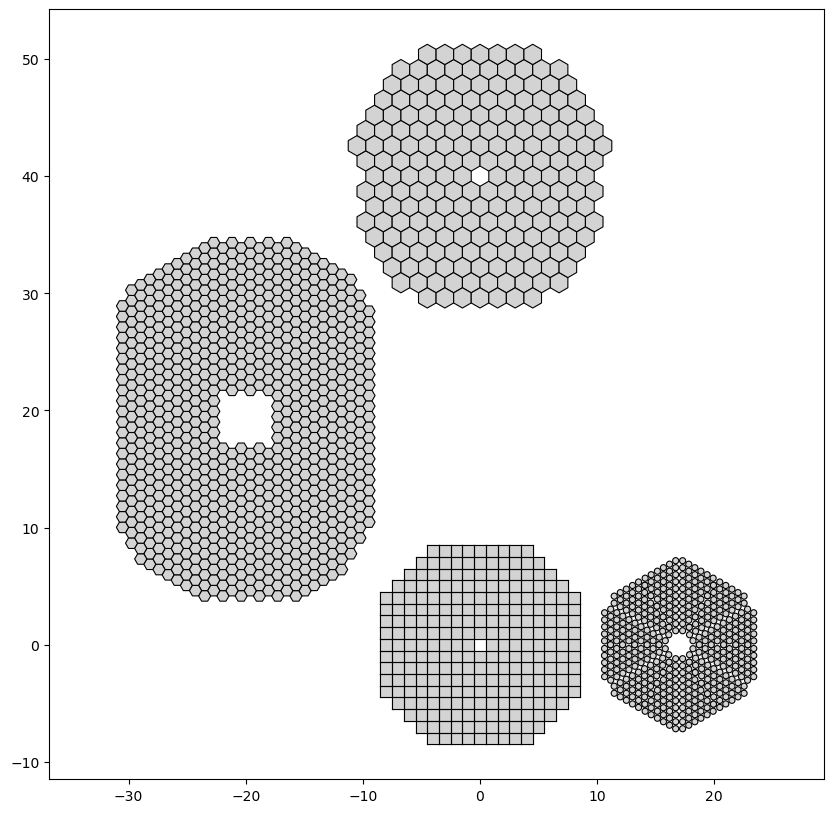

In [4]:
fig, ax = plt.subplots(figsize=(10, 10))

plot_hess12(ax, x_center=17.0, y_center=0.0, mirror_size_scale=1., lw=0.8, c="k", fc="lightgray")
plot_lst(ax, 0, 40, mirror_separation=0.0, lw=0.8, c="k", fc="lightgray")
plot_magic(ax, x_center=0.0, y_center=0.0, mirror_separation=0.0, lw=0.8, c="k", fc="lightgray")
plot_hess28(ax, -20, 19, mirror_separation=0.0, lw=0.8, c="k", fc="lightgray")

ax.axis("equal")

# plt.axis('off')
plt.show()

In [33]:
def plot_mst(ax, x_center=0.0, y_center=0.0, mirror_separation=0.0, lw=0.8, c="k", fc="lightgray", **kwargs):
    # MST mirrors are 1.2m flat-to-flat
    # https://indico.icc.ub.edu/event/46/contributions/1335/attachments/461/852/ID453_HeikoSalzmann_actuator_testing_CTA_MSTs.pdf
    # Then we convert flat-to-flat to radius
    mirror_radius=(1.2 / 2 / np.cos(np.deg2rad(30)))

    # Hard-coded factors. Given the way the geometry was defined initially.
    s = np.sqrt(3)/2
    size_factor = mirror_radius * np.sqrt(3)
    r_rings = np.arange(-5, 6)

    # Relative separation between mirrors
    relative_separation = (mirror_radius - mirror_separation / 2) / mirror_radius
    
    positions_hex = []
    for y in r_rings:
        if y in r_rings[:] and y != 0:
            positions_hex.append((0, y))
        for yf in [-1,1]:
            if y in r_rings[1:]:
                positions_hex.append((s * 1 * yf, y - 0.5))
            if y in r_rings[1:-1]:
                positions_hex.append((s * 2 * yf, y))
            if y in r_rings[2:-1]:
                positions_hex.append((s * 3 * yf, y - 0.5))
            if y in r_rings[2:-2]:
                positions_hex.append((s * 4 * yf, y))
            if y in r_rings[3:-2]:
                positions_hex.append((s * 5 * yf, y - 0.5))

    for position_hex in positions_hex:
        _x, _y = position_hex
        x_hex = (_x * size_factor + x_center)
        y_hex = (_y * size_factor + y_center)
        Hexagon = RegularPolygon((x_hex, y_hex), numVertices=6, radius=mirror_radius * relative_separation, 
                                 edgecolor=c, orientation=np.pi/2, lw=lw, facecolor=fc, **kwargs)
        ax.add_patch(Hexagon)

def plot_sst(ax, x_center=0.0, y_center=0.0, mirror_separation=0.0, lw=0.8, c="k", fc="lightgray", **kwargs):

    # SST mirrors are 0.78m flat-to-flat
    # https://veritas.sao.arizona.edu/~benbow/Mirror_Poster.pdf
    # Then we convert flat-to-flat to radius
    mirror_radius=(0.78 / 2 / np.cos(np.deg2rad(30)))

    
    # Hard-coded factors. Given the way the geometry was defined initially.
    s = np.sqrt(3)/2
    size_factor = mirror_radius * np.sqrt(3)
    r_rings = np.arange(-2, 3)

    # Relative separation between mirrors
    relative_separation = (mirror_radius - mirror_separation / 2) / mirror_radius

    positions_hex = []       
    for r in r_rings:
        if r != 0 and  r in r_rings[:]:
            positions_hex.append((r, 0))
        for yf in [1,-1]:
            if r in r_rings[:-1]:
                positions_hex.append((r + 0.5, s * yf))  
            if r in r_rings[1:-1]:
                positions_hex.append((r, s * 2 * yf))


    for position_hex in positions_hex:
        _x, _y = position_hex
        x_hex = (_x * size_factor + x_center)
        y_hex = (_y * size_factor + y_center)
        Hexagon = RegularPolygon((x_hex, y_hex), numVertices=6, radius=mirror_radius * relative_separation, 
                                 edgecolor=c, lw=lw, facecolor=fc, **kwargs)
        ax.add_patch(Hexagon)
        

In [34]:

def plot_veritas(ax, x_center=0.0, y_center=0.0, mirror_separation=0.0, lw=0.8, c="k", fc="lightgray", **kwargs):

    # VERITAS mirrors are 0.61m flat-to-flat
    # https://veritas.sao.arizona.edu/~benbow/Mirror_Poster.pdf
    # Then we convert flat-to-flat to radius
    mirror_radius=(0.61 / 2 / np.cos(np.deg2rad(30)))

    
    # Hard-coded factors. Given the way the geometry was defined initially.
    s = np.sqrt(3)/2
    size_factor = mirror_radius * np.sqrt(3)
    r_rings = np.arange(-10, 11)

    # Relative separation between mirrors
    relative_separation = (mirror_radius - mirror_separation / 2) / mirror_radius

    positions_hex = []
    for r in r_rings:
        if r != 0 and  r not in r_rings[9:-9] and r!=-7 and r!=7 and r in r_rings[1:-1]:
            positions_hex.append((r, 0))        
        for yf in [1,-1]:
            if r in r_rings[:-1] and r not in r_rings[9:-10]:
                positions_hex.append((r + 0.5, s * yf))
            if r in r_rings[1:-1]:
                positions_hex.append((r, s * 2 * yf))
            if r in r_rings[:-1]:
                 positions_hex.append((r + 0.5, s * 3 * yf))
            if r in r_rings[2:-2]:
                positions_hex.append((r, s * 4 * yf))                
            if r in r_rings[1:-2]:
                positions_hex.append((r + 0.5, s * 5 * yf))
            if r in r_rings[2:-2]:
                positions_hex.append((r, s * 6 * yf))
            if r in r_rings[2:-3]:
                positions_hex.append((r + 0.5, s * 7 * yf))
            if r in r_rings[3:-3] and r not in r_rings[10:-10]:
                positions_hex.append((r, s * 8 * yf))
            if r in r_rings[4:-5]:
                positions_hex.append((r + 0.5, s * 9 * yf))
            if r in r_rings[6:-6]:
                positions_hex.append((r, s * 10 * yf))
            if r in r_rings[7:-8]:
                positions_hex.append((r + 0.5, s * 11 * yf))

    for position_hex in positions_hex:
        _x, _y = position_hex
        x_hex = (_x * size_factor + x_center)
        y_hex = (_y * size_factor + y_center)
        Hexagon = RegularPolygon((x_hex, y_hex), numVertices=6, radius=mirror_radius * relative_separation, 
                                 edgecolor=c, lw=lw, facecolor=fc, **kwargs)
        ax.add_patch(Hexagon)

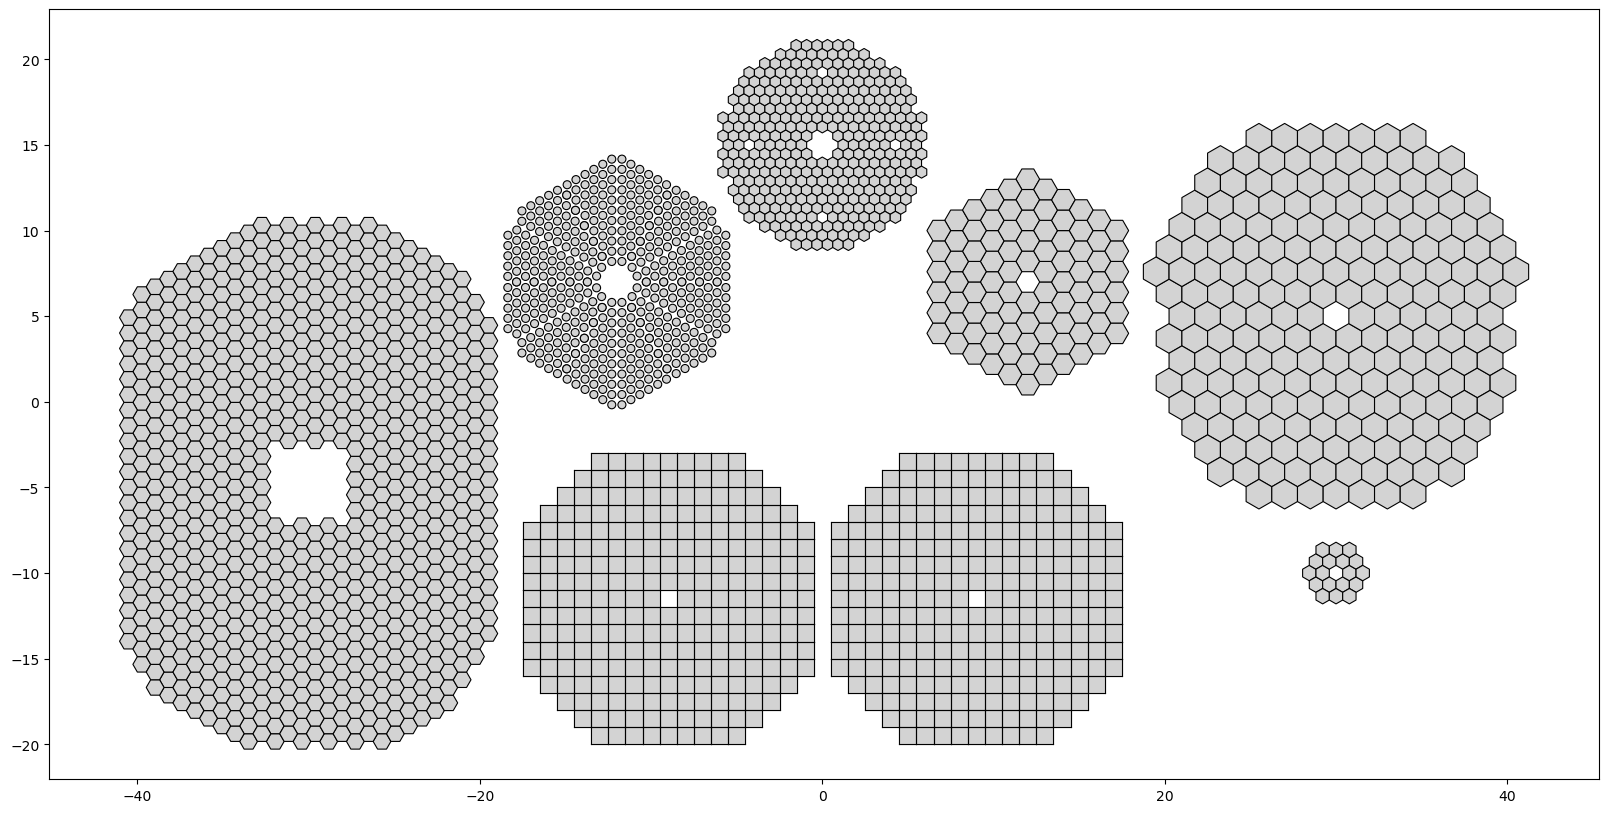

In [37]:
fig, ax = plt.subplots(figsize=(20, 10))

plot_hess12(ax, -12, 7, mirror_size_scale=0.9, lw=0.8, c="k", fc="lightgray")
plot_lst(ax, 30, 5, mirror_separation=0.0, lw=0.8, c="k", fc="lightgray")
plot_sst(ax, 30, -10, mirror_separation=0.0, lw=0.8, c="k", fc="lightgray")
plot_veritas(ax, 0, 15, mirror_separation=0.0, lw=0.8, c="k", fc="lightgray")
plot_mst(ax, 12, 7, mirror_separation=0.0, lw=0.8, c="k", fc="lightgray")
plot_magic(ax, 9, -11.5, mirror_separation=0.0, lw=0.8, c="k", fc="lightgray")
plot_magic(ax, -9, -11.5, mirror_separation=0.0, lw=0.8, c="k", fc="lightgray")
plot_hess28(ax, -30, -5, mirror_separation=0.0, lw=0.8, c="k", fc="lightgray")

ax.axis("equal")

# plt.axis('off')
plt.show()